<a href="https://colab.research.google.com/github/nasiksami/NCT/blob/main/Test_of_ML_Algorithms_on_NTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **AUTOMATIC PAIN RECOGNITION SYSTEM FOR DENTAL PATIENTS USING MACHINE LEARNING **

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, make_scorer
from time import time

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Loading and Analyzing the data**




In [ ]:
from sklearn.utils import shuffle
df = pd.read_csv('/content/drive/MyDrive/fyp/data.csv')

In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split

# # Load your dataset
# #df = pd.read_csv('/path/to/your_dataset.csv')

# # Determine the class distribution
# class_distribution = df['pain_level'].value_counts()

# # Calculate the desired number of rows for each class in the test set
# test_size = 1000
# test_ratio = test_size / sum(class_distribution)
# test_rows_per_class = (class_distribution * test_ratio).astype(int)

# # Initialize an empty DataFrame for the test set
# test_df = pd.DataFrame()

# # Create the test set by preserving the class distribution
# for cls in class_distribution.index:
#     class_subset = df[df['pain_level'] == cls].sample(test_rows_per_class[cls], random_state=42)
#     test_df = pd.concat([test_df, class_subset])

# # Separate the target variable (pain_level) from the features in the test set
# X_test = test_df.drop('pain_level', axis=1)  # Features
# y_test = test_df['pain_level']  # Target variable

# # Filter the remaining data (training data) based on the test set indices
# train_indices = df.index.difference(test_df.index)
# train_df = df.loc[train_indices]

# # Separate the target variable (pain_level) from the features in the training set
# X_train = train_df.drop('pain_level', axis=1)  # Features
# y_train = train_df['pain_level']  # Target variable

# # Perform further processing or analysis on X_train, y_train, X_test, and y_test


In [ ]:
df.shape

(100000, 8)

In [ ]:
df.head()
#df.drop('Unnamed: 0', inplace=True, axis=1)
df.dtypes

Unnamed: 0      int64
pain level     object
ECG           float64
EMG           float64
EEG1          float64
EEG2          float64
EEG3          float64
EEG4          float64
dtype: object

In [ ]:
df.dropna(inplace=True)

In [ ]:
df = df.sample(frac = 1)

In [ ]:
df.head()

,Unnamed: 0,pain level,ECG,EMG,EEG1,EEG2,EEG3,EEG4
9640,9640,mild pain,69.0,0.281,0.318,0.160,0.337,0.313
68740,68740,high pain,131.0,0.772,0.562,0.576,0.972,0.919
75869,75869,no pain,63.0,0.027,0.218,0.342,0.363,0.074
24415,24415,mild pain,66.0,0.228,0.208,0.219,0.088,0.400
97397,97397,mild pain,95.0,0.620,0.537,0.547,0.659,0.625


In [ ]:
df = df.drop("Unnamed: 0", axis=1)

In [ ]:
df = df.rename(columns={"pain level": "pain_level"})


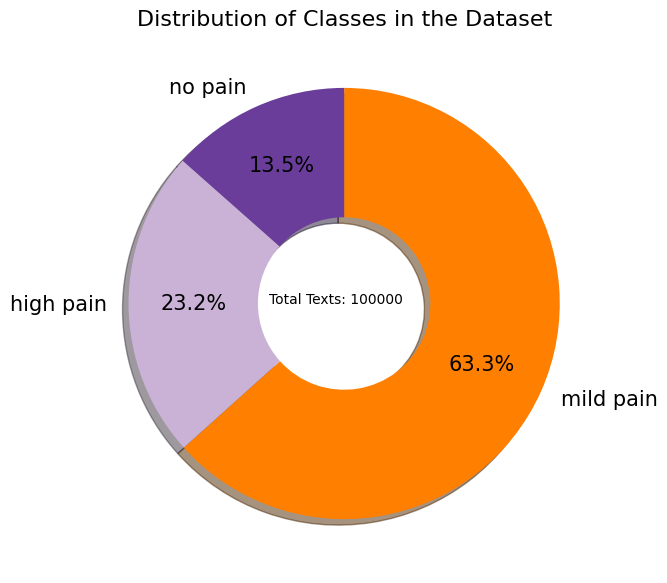

In [ ]:
plt.figure(figsize = (7,7))
sorted_counts = df['pain_level'].value_counts()
plt.pie(sorted_counts, labels = sorted_counts.index, startangle = 90, counterclock = False, wedgeprops = {'width' : 0.6},
       autopct='%1.1f%%', pctdistance = 0.7, textprops = {'color': 'black', 'fontsize' : 15}, shadow = True,
        colors = sns.color_palette("Paired")[7:])
plt.text(x = -0.35, y = 0, s = 'Total Texts: {}'.format(df.shape[0]))
plt.title('Distribution of Classes in the Dataset', fontsize = 16);

In [ ]:
df['pain_level'] = df.pain_level.map({'high pain':3,'mild pain':2,"no pain":1})

In [ ]:
df.shape

(100000, 7)

In [ ]:
df.head()

,pain_level,ECG,EMG,EEG1,EEG2,EEG3,EEG4
9640,2,69.0,0.281,0.318,0.160,0.337,0.313
68740,3,131.0,0.772,0.562,0.576,0.972,0.919
75869,1,63.0,0.027,0.218,0.342,0.363,0.074
24415,2,66.0,0.228,0.208,0.219,0.088,0.400
97397,2,95.0,0.620,0.537,0.547,0.659,0.625


In [ ]:
df.isna().sum()

pain_level    0
ECG           0
EMG           0
EEG1          0
EEG2          0
EEG3          0
EEG4          0
dtype: int64

In [ ]:
df.shape

(100000, 7)

In [ ]:
df.drop_duplicates(inplace=True)

# **Implementing a training and predicting Pipeline**

---



In [ ]:
X = df.drop('pain_level', axis=1)  # Independent features
y = df['pain_level']  # Dependent feature

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
df.head()

,pain_level,ECG,EMG,EEG1,EEG2,EEG3,EEG4
9640,2,69.0,0.281,0.318,0.160,0.337,0.313
68740,3,131.0,0.772,0.562,0.576,0.972,0.919
75869,1,63.0,0.027,0.218,0.342,0.363,0.074
24415,2,66.0,0.228,0.208,0.219,0.088,0.400
97397,2,95.0,0.620,0.537,0.547,0.659,0.625


In [ ]:
#Defining the pipeline function

def pipeline(learner_list, X_train, y_train, X_test, y_test):
    '''
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    '''

    # Get length of Training Data:
    size = len(y_train)

    results = {}
    final_results = []

    for learner in learner_list:

        # Store the learner name:
        results['Algorithm'] = learner.__class__.__name__

        # Fit the learner:
        start = time() # Get start time
        print("Training {}".format(learner.__class__.__name__))
        learner = learner.fit(X_train, y_train)
        end = time() # Get end time

        # Store the training time
        results['Training Time'] = end - start

        start = time() # Get start time
        predictions_test = learner.predict(X_test)
        predictions_train = learner.predict(X_train)
        end = time() # Get end time

        # Store the prediction time
        results['Prediction Time'] = end - start

        # Compute the Accuracy on Test Set
        results['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

        # Compute the Accuracy on Training Set
        results['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

        # Compute the F1 Score on Test Set
        results['F1 Score: Test'] = f1_score(y_test, predictions_test, average='macro')

        # Compute the F1 Score on Training Set
        results['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

        # Compute the Precision on Test Set
        results['Precision: Test'] = precision_score(y_test, predictions_test,average='macro')

        # Compute the Precision on Training Set
        results['Precision: Train'] = precision_score(y_train, predictions_train,average='macro')

        # Compute the Recall on Test Set
        results['Recall: Test'] = recall_score(y_test, predictions_test,average='macro')

        # Compute the Recall on Training Set
        results['Recall: Train'] = recall_score(y_train, predictions_train,average='macro')

        # Success
        print("Training {} finished in {:.2f} sec".format(learner.__class__.__name__, results['Training Time']))
        print('----------------------------------------------------')

        final_results.append(results.copy())
    # Return a dataframe of the results
    return final_results


## **Put Algorithms in Pipeline**

In [ ]:
# making a list of models
models = [MultinomialNB(), DecisionTreeClassifier(), LinearSVC(), AdaBoostClassifier(),
          BaggingClassifier(),RandomForestClassifier(),
         LogisticRegression(), SGDClassifier(), KNeighborsClassifier()]
         #

In [ ]:
re = pipeline(models, X_train, y_train, X_test, y_test)
results = pd.DataFrame(re)
results = results.reindex(columns = ['Algorithm', 'Accuracy: Test', 'Precision: Test', 'Recall: Test', 'F1 Score: Test', 'Prediction Time',
                          'Accuracy: Train', 'Precision: Train', 'Recall: Train', 'F1 Score: Train', 'Training Time'])

Training MultinomialNB
Training MultinomialNB finished in 0.03 sec
----------------------------------------------------
Training DecisionTreeClassifier


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Training DecisionTreeClassifier finished in 0.52 sec
----------------------------------------------------
Training LinearSVC


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Training LinearSVC finished in 21.55 sec
----------------------------------------------------
Training AdaBoostClassifier


...

Training AdaBoostClassifier finished in 2.39 sec
----------------------------------------------------
Training BaggingClassifier
Training BaggingClassifier finished in 3.25 sec
----------------------------------------------------
Training RandomForestClassifier
Training RandomForestClassifier finished in 16.30 sec
----------------------------------------------------
Training LogisticRegression


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training LogisticRegression finished in 2.68 sec
----------------------------------------------------
Training SGDClassifier


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Training SGDClassifier finished in 8.89 sec
----------------------------------------------------
Training KNeighborsClassifier
Training KNeighborsClassifier finished in 0.08 sec
----------------------------------------------------


In [ ]:
results = results.reindex(columns = ['Algorithm', 'Accuracy: Test', 'Precision: Test', 'Recall: Test', 'F1 Score: Test', 'Prediction Time',
                          'Accuracy: Train', 'Precision: Train', 'Recall: Train', 'F1 Score: Train', 'Training Time'])

results.sort_values(by = 'F1 Score: Test', inplace = True, ascending = False)

In [ ]:
import pickle
model_folder_path = '/content/drive/MyDrive/fyp/models/'
# Save each model
for index, row in results.iterrows():
    algorithm = row['Algorithm']
    model = models[index]  # Retrieve the corresponding model
    model_filename = model_folder_path + algorithm + '.pickle'
    with open(model_filename, 'wb') as file:
        pickle.dump(model, file)


## **Analyze the results of the Pipeline**




In [ ]:
results.reset_index(drop = True)

,Algorithm,Accuracy: Test,Precision: Test,Recall: Test,F1 Score: Test,Prediction Time,Accuracy: Train,Precision: Train,Recall: Train,F1 Score: Train,Training Time
0,RandomForestClassifier,0.65248,0.566650,0.565740,0.566186,2.610970,1.000000,1.000000,1.000000,1.000000,16.299760
1,KNeighborsClassifier,0.64280,0.561050,0.574396,0.564513,5.212844,0.761400,0.698643,0.718957,0.704595,0.078051
2,BaggingClassifier,0.64236,0.554721,0.551534,0.549058,0.239612,0.988760,0.986051,0.986206,0.986057,3.246934
3,DecisionTreeClassifier,0.62676,0.530108,0.528675,0.529382,0.024533,1.000000,1.000000,1.000000,1.000000,0.522014
4,LogisticRegression,0.63640,0.540076,0.432183,0.439255,0.010510,0.636653,0.540017,0.431742,0.437421,2.679721
5,LinearSVC,0.61172,0.370947,0.575462,0.433262,0.009361,0.610493,0.370262,0.573723,0.432047,21.547823
6,SGDClassifier,0.62592,0.354577,0.441551,0.392081,0.008207,0.625627,0.354794,0.442586,0.392756,8.891580
7,AdaBoostClassifier,0.63248,0.343932,0.346526,0.288765,0.509567,0.633493,0.355698,0.349106,0.293375,2.393205
8,MultinomialNB,0.63340,0.211133,0.333333,0.258520,0.010087,0.633493,0.211164,0.333333,0.258543,0.033949


In [ ]:
results.describe().loc[['min', 'max'], :]

,Accuracy: Test,Precision: Test,Recall: Test,F1 Score: Test,Prediction Time,Accuracy: Train,Precision: Train,Recall: Train,F1 Score: Train,Training Time
min,0.61172,0.211133,0.333333,0.258520,0.008207,0.610493,0.211164,0.333333,0.258543,0.033949
max,0.65248,0.566650,0.575462,0.566186,5.212844,1.000000,1.000000,1.000000,1.000000,21.547823


In [ ]:
# store the best metric scores
best_acc = results[results['Accuracy: Test'] == results['Accuracy: Test'].max()]
best_f1 = results[results['F1 Score: Test'] == results['F1 Score: Test'].max()]
best_precision = results[results['Precision: Test'] == results['Precision: Test'].max()]
best_recall = results[results['Recall: Test'] == results['Recall: Test'].max()]

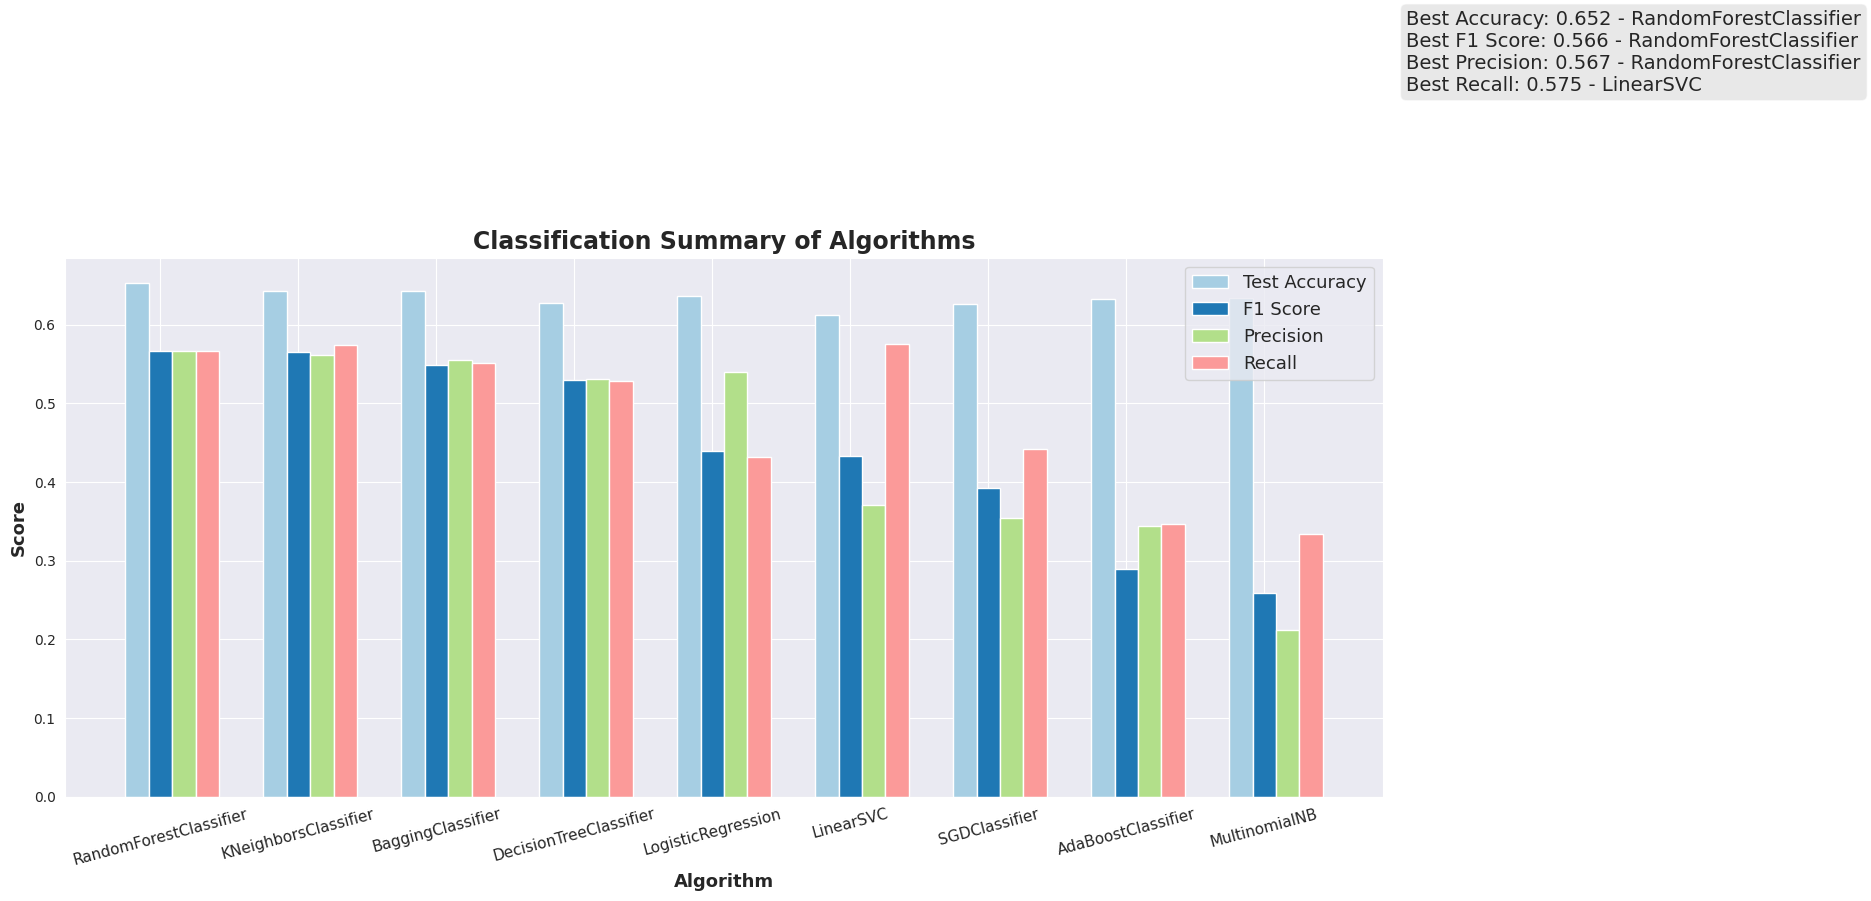

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize = (17, 7))

barWidth = 0.17

# set height of bar
bars1 = results['Accuracy: Test']
bars2 = results['F1 Score: Test']
bars3 = results['Precision: Test']
bars4 = results['Recall: Test']


# Set position of bar on X axis
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]


# Make the plot
pal = sns.color_palette("Paired")
plt.bar(r1, bars1, color= pal[0], width=barWidth, edgecolor='white', label='Test Accuracy')
plt.bar(r2, bars2, color= pal[1], width=barWidth, edgecolor='white', label='F1 Score')
plt.bar(r3, bars3, color= pal[2], width=barWidth, edgecolor='white', label='Precision')
plt.bar(r4, bars4, color= pal[4], width=barWidth, edgecolor='white', label='Recall')


# Add xticks on the middle of the group bars
plt.xlabel('Algorithm', fontweight='bold', fontsize = 13)
plt.ylabel('Score', fontweight = 'bold', fontsize = 13)
plt.xticks([r + barWidth for r in range(len(bars1))], results['Algorithm'], rotation = 15, fontsize = 11)

# Create legend & Show graphic
plt.legend(fontsize = 13)

textstr = '\n'.join(['Best Accuracy: {:.3f} - {}'.format(best_acc['Accuracy: Test'].values[0], best_acc['Algorithm'].values[0]),
                     'Best F1 Score: {:.3f} - {}'.format(best_f1['F1 Score: Test'].values[0], best_f1['Algorithm'].values[0]),
                   'Best Precision: {:.3f} - {}'.format(best_precision['Precision: Test'].values[0], best_precision['Algorithm'].values[0]),
                    'Best Recall: {:.3f} - {}'.format(best_recall['Recall: Test'].values[0], best_recall['Algorithm'].values[0])])
props = dict(boxstyle='round', facecolor='lightgrey', alpha=0.5)

#place a text box
plt.text(9.2, 1, textstr, fontsize=14,
        verticalalignment='top', bbox=props)

plt.title('Classification Summary of Algorithms', fontweight = 'bold', fontsize = 17);


In [ ]:

# store the best/worst performance time
best_train_time = results[results['Training Time'] == results['Training Time'].min()]
worst_train_time = results[results['Training Time'] == results['Training Time'].max()]
best_prediction_time = results[results['Prediction Time'] == results['Prediction Time'].min()]
worst_prediction_time = results[results['Prediction Time'] == results['Prediction Time'].max()]

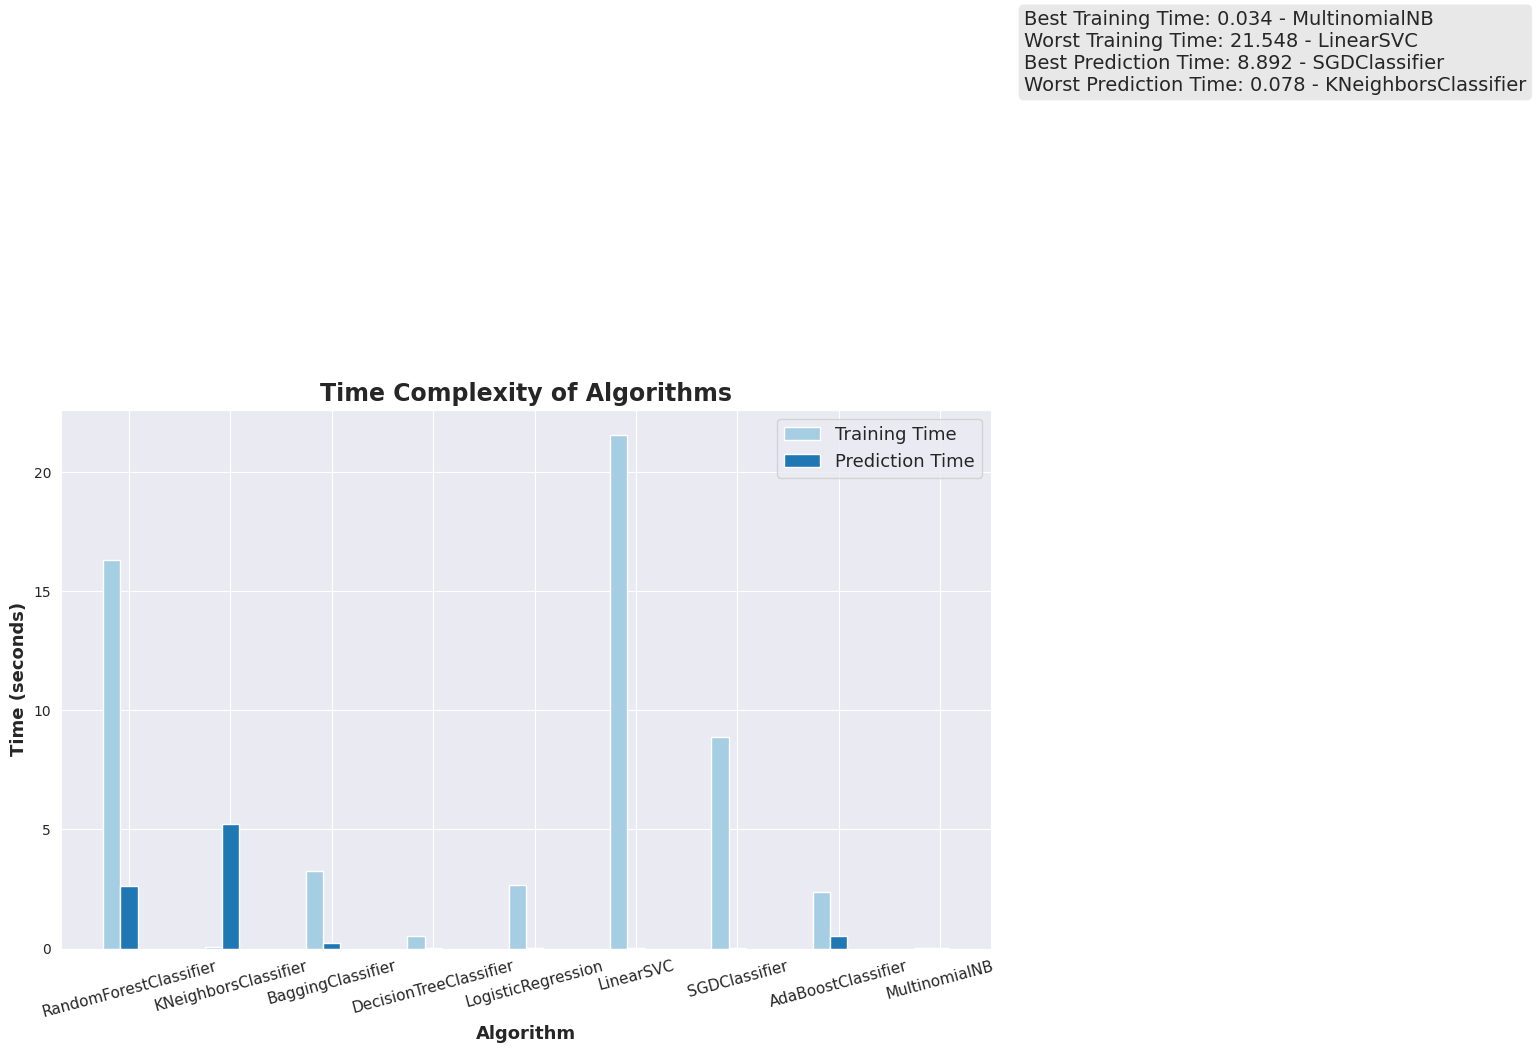

In [ ]:
plt.figure(figsize = (12, 7))

barWidth = 0.17

# set height of bar
bars1 = results['Training Time']
bars2 = results['Prediction Time']

# Set position of bar on X axis
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]

# Make the plot
plt.bar(r1, bars1, color= pal[0], width=barWidth, edgecolor='white', label='Training Time')
plt.bar(r2, bars2, color= pal[1], width=barWidth, edgecolor='white', label='Prediction Time')

# Add xticks on the middle of the group bars
plt.xlabel('Algorithm', fontweight='bold', fontsize = 13)
plt.ylabel('Time (seconds)', fontweight = 'bold', fontsize = 13)
plt.xticks([r + barWidth for r in range(len(bars1))], results['Algorithm'], rotation = 15, fontsize = 11)

# Create legend & Show graphic
plt.legend(fontsize = 13)

textstr = '\n'.join(('Best Training Time: {:.3f} - {}'.format(best_train_time['Training Time'].values[0], best_train_time['Algorithm'].values[0]),
                     'Worst Training Time: {:.3f} - {}'.format(worst_train_time['Training Time'].values[0], worst_train_time['Algorithm'].values[0]),
                   'Best Prediction Time: {:.3f} - {}'.format(best_prediction_time['Training Time'].values[0], best_prediction_time['Algorithm'].values[0]),
                    'Worst Prediction Time: {:.3f} - {}'.format(worst_prediction_time['Training Time'].values[0], worst_prediction_time['Algorithm'].values[0])))

props = dict(boxstyle='round', facecolor='lightgrey', alpha=0.5)

#place a text box
plt.text(9, 36, textstr, fontsize=14,  bbox=props)

plt.title('Time Complexity of Algorithms', fontweight = 'bold', fontsize = 17);

## **Demo Application**

In [ ]:
# Load each model
loaded_models = {}
for index, row in results.iterrows():
    algorithm = row['Algorithm']
    model_filename = model_folder_path + algorithm + '.pickle'
    with open(model_filename, 'rb') as file:
        loaded_models[algorithm] = pickle.load(file)


In [ ]:
# Function to make predictions using a selected model
def predict_with_model(model_name, data):
    model = loaded_models[model_name]
    predictions = model.predict(data)
    return predictions

In [ ]:
algorithm_names = results['Algorithm'].unique()
for name in algorithm_names:
    print(name)

RandomForestClassifier
KNeighborsClassifier
BaggingClassifier
DecisionTreeClassifier
LogisticRegression
LinearSVC
SGDClassifier
AdaBoostClassifier
MultinomialNB


In [ ]:
# Function to make predictions using a selected model
def predict_with_model(model_name, data):
    model = loaded_models[model_name]
    predictions = model.predict(data)
    probabilities = model.predict_proba(data)
    return predictions, probabilities


# Example custom input data
custom_data = np.array([[100, 0.168, 0.645, 0.65, 0.74, 0.2]])

# Make predictions with a selected model
selected_model = 'LogisticRegression'
predictions, probabilities = predict_with_model(selected_model, custom_data)

# Reverse mapping dictionary
reverse_mapping = {1: 'no pain', 2: 'mild pain', 3: 'high pain'}

# Convert predictions to original values
predicted_labels = [reverse_mapping[prediction] for prediction in predictions]

# Get the prediction probabilities for each class
prediction_probabilities = probabilities[0]

# Create a dictionary of class labels and their corresponding probabilities
prediction_results = {
    'Class': list(reverse_mapping.values()),
    'Probability': prediction_probabilities
}

# Create a dataframe from the prediction results
prediction_df = pd.DataFrame(prediction_results)

# Print the predicted labels and their probabilities
print("The prediction of the input result :" ,predicted_labels)
print(prediction_df)

The prediction of the input result : ['high pain']
       Class  Probability
0    no pain     0.000002
1  mild pain     0.021089
2  high pain     0.978909


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
